In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path
cur_dir = Path.cwd()
cur_dir

PosixPath('/home/niger/projects/solvro/ml/ml-wakacyjne-wyzwanie-2026/zad2')

In [3]:
zad1_path = cur_dir.parent / "zad1"

In [4]:
zad1_path



PosixPath('/home/niger/projects/solvro/ml/ml-wakacyjne-wyzwanie-2026/zad1')

In [5]:
titanic_df = pd.read_csv(zad1_path / "titanic_output.csv")

In [6]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Survived           891 non-null    int64  
 1   Pclass             891 non-null    int64  
 2   Sex                891 non-null    int64  
 3   Age                891 non-null    float64
 4   SibSp              891 non-null    int64  
 5   Parch              891 non-null    int64  
 6   Fare               891 non-null    float64
 7   Embarked_C         891 non-null    int64  
 8   Embarked_Q         891 non-null    int64  
 9   Embarked_S         891 non-null    int64  
 10  Cabin_A            891 non-null    int64  
 11  Cabin_B            891 non-null    int64  
 12  Cabin_C            891 non-null    int64  
 13  Cabin_D            891 non-null    int64  
 14  Cabin_E            891 non-null    int64  
 15  Cabin_F            891 non-null    int64  
 16  Cabin_G            891 non-null    in

In [7]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,...,Cabin_Unknown,Name_Dr.,Name_Master.,Name_Miss.,Name_Mr.,Name_Mrs.,Name_Rev.,Name_unusual,Pclass_Fare_Ratio,Family
0,0,3,0,22.0,1,0,7.2500,0,0,1,...,1,0,0,0,1,0,0,0,0.519254,1
1,1,1,1,38.0,1,0,71.2833,1,0,0,...,0,0,0,0,0,1,0,0,0.897659,1
2,1,3,1,26.0,0,0,7.9250,0,0,1,...,1,0,0,1,0,0,0,0,0.567598,0
3,1,1,1,35.0,1,0,53.1000,0,0,1,...,0,0,0,0,0,1,0,0,0.668680,1
4,0,3,0,35.0,0,0,8.0500,0,0,1,...,1,0,0,0,1,0,0,0,0.576551,0


In [8]:
titanic_copy = titanic_df.copy()

wszystko się poprawnie zaimportowało więc wpierw warto podzielić zbiór danych aby zapobiec data leakage ponadto podczas podziału warto zachować proporcjonalność danych zwłaszcza tych które niosą sporą informacje o przeżywalności z zad1 na pewno takimi cechami są Cabin_Unknown i Sex, oraz zdecydowanie proporcjonalnie podzielona musi być przeżywalność zrobię to po prostu poprzez sampling tych cech, reszty trochę mi się nie chcę samplować

In [9]:
def df_splitting(df, Sex, Cabin_Unknown, Survived):
    return df[(df["Sex"]==Sex) & (df["Cabin_Unknown"]==Cabin_Unknown) & (df["Survived"]==Survived)].index

In [10]:


from sklearn.model_selection import train_test_split
def train_test_spliting(df, ratio):#dzieli na zbiór treningowy i testowyu
    df_shuffled = df.sample(frac=1.0,random_state=42).reset_index(drop=True) #tak jakby tasuje dane
    categorial_samples_indices={}
    train_id=[]
    test_id=[]
    val_id=[]
    for Sex in [0,1]:
        for Cabin_Unknown in [0,1]:
            for Survived in [0,1]:
                categorial_samples_indices[(Sex,Cabin_Unknown,Survived)] = df_splitting(df_shuffled, Sex, Cabin_Unknown, Survived)

    for key in categorial_samples_indices:
        if len(categorial_samples_indices[key]):
            train_sample , test_sample = train_test_split(categorial_samples_indices[key], test_size=ratio, random_state=42)
            train_id.extend(train_sample)
            test_id.extend(test_sample)
    return (df_shuffled.loc[train_id], df_shuffled.loc[test_id])


In [11]:
train, test = train_test_spliting(titanic_df, 0.3)
test, valid = train_test_spliting(test, 0.5)#tworzę jeszcze zbiór walidacyjny
titanic_df=train.copy()

skoro mam podzielony zbiór to czas przeskalować cechy ciągłe takie jak (Fare, age, Pclass_Fare_Ratio) , oraz kategorialne uporządkowane (Family, Pclass, SibSp, Parch, Family), zanim to zrobię przypomnę jak wygląda rozkład tych cech na histogramach

<Axes: >

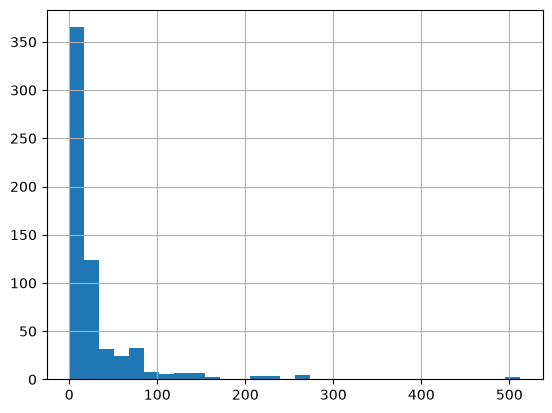

In [12]:
titanic_df['Fare'].hist(bins = 30)

highkey jest to rozkład prawoogonowy czy jakoś tak więc jeszcze trzeba będzie to zlogarytmować

<Axes: >

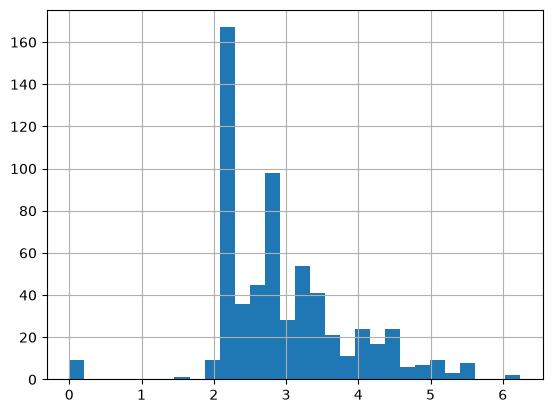

In [13]:
titanic_df["Fare"] = np.log1p(titanic_df['Fare'])#funkcja ta liczy ln(x+1) dzięki czemu działa dla 0
titanic_df['Fare'].hist(bins = 30)

z tego jak wygląda to po zlogarytmowaniu to lepiej wybrać robloxscaler bo jest to 0 odstające

<Axes: >

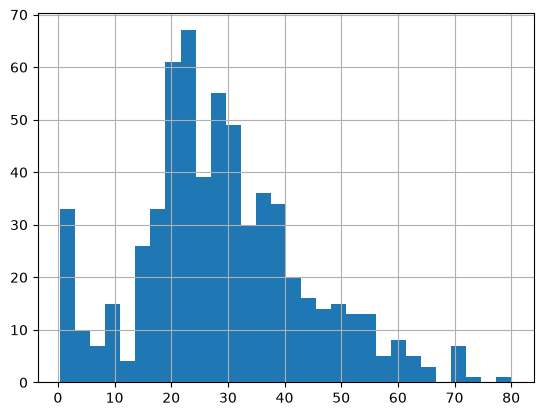

In [14]:
titanic_df["Age"].hist(bins=30)

tak jak w poprzednim przypadku nie przypomina to rozkładu normalnego i standard scaler będzie najleprzym wyborem

<Axes: >

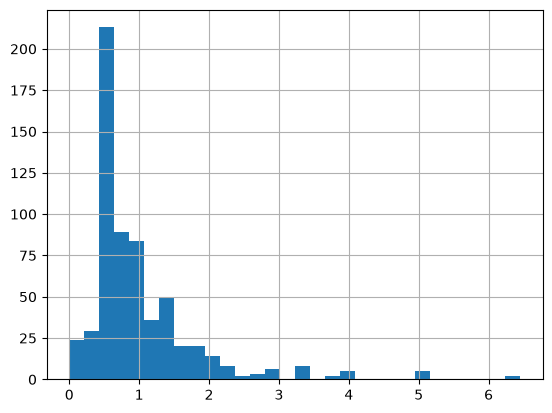

In [15]:
titanic_df["Pclass_Fare_Ratio"].hist(bins=30)

to bym zlogarytmował  bo znowu mocno prawoogonowy rozkład

<Axes: >

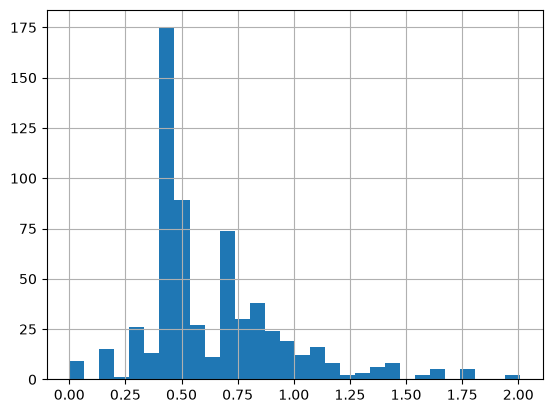

In [16]:
titanic_df["Pclass_Fare_Ratio"] = np.log1p(titanic_df["Pclass_Fare_Ratio"])

titanic_df["Pclass_Fare_Ratio"].hist(bins=30)

tutaj bym użył robust scalera bo sporo jest niewielkich słupków przesuniętych na prawo które są outlinerami

jeszcze została kwestia posortowanych wartości kategorialnycj ale tutaj chyba najlepiej będzie podzielić przez maksymalną wartość + 2 jakby na wypadek model dostał wartość wyższą niż ta z którą ma doczynienia

In [17]:
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer

class log_trans:
    def __init__(self, transf):
        self.transformer = transf
        self.log_transformer = FunctionTransformer(np.log1p)
    def fit(self, X, y=None): #dodałem y jako że wiele elementów z skikit learn przyjmuje że jest on w fit
        loged_X = self.log_transformer.transform(X)
        self.transformer.fit(loged_X)
        return self #w sci kit fit ma zwracać self
    def transform(self, X):
        loged_X = self.log_transformer.transform(X)
        return self.transformer.transform(loged_X)
    def fit_transform(self,X,y=None):
        return self.fit(X,y).transform(X)

class ordinal_cat_transformer: #po prostu dzieli cechy ordinal categorial przez max wartość +2 na wypadek jakby do danych testowych wpadło coś co ma więcej wartości
    def __init__(self):
        self.max=0

    def fit(self, X, y=None):
        self.max= X.max()
        return self
    def transform(self,X):
        return X/ (self.max+2)
    def fit_transform(self,X,y=None):
        return self.fit(X,y).transform(X)
        

class titanic_transformer:
    def __init__(self):
        self.scalers={
            "Age": StandardScaler(),
            "Fare":log_trans(RobustScaler()),
            "Pclass_Fare_Ratio":log_trans(RobustScaler()),
            "Pclass":ordinal_cat_transformer(),
            "SibSp":ordinal_cat_transformer(),
            "Parch":ordinal_cat_transformer(),
            "Family":ordinal_cat_transformer()#to są jedyne cechy do stransformowania reszta to 0 i 1
        }
    def fit(self,df):
        for col in self.scalers:
            self.scalers[col].fit(df[[col]])
        return self
    def transform(self, df, inplace=False):
        if inplace:
            titanic=df
        else:
            titanic=df.copy()
        for col in self.scalers:
            titanic[col]=self.scalers[col].transform(titanic[[col]])
        return titanic
    def fit_transform(self, df, inplace = False):
        return self.fit(df).transform(df,inplace=inplace)
            

In [18]:
main_transformer = titanic_transformer()
main_transformer.fit_transform(train,inplace=True)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,...,Cabin_Unknown,Name_Dr.,Name_Master.,Name_Miss.,Name_Mr.,Name_Mrs.,Name_Rev.,Name_unusual,Pclass_Fare_Ratio,Family
117,0,0.4,0,0.469030,0.0,0.000,-0.091733,1,0,0,...,0,0,0,0,1,0,0,0,-0.068066,0.000000
114,0,0.2,0,-0.750371,0.0,0.000,2.207656,0,0,1,...,0,0,0,0,1,0,0,0,2.510719,0.000000
445,0,0.2,0,2.365875,0.0,0.000,0.476397,0,0,1,...,0,0,0,0,1,0,0,0,-0.711186,0.000000
92,0,0.2,0,2.162642,0.0,0.000,0.633919,0,0,1,...,0,0,0,0,1,0,0,0,-0.547633,0.000000
689,0,0.2,0,0.672263,0.0,0.000,-2.270190,0,0,1,...,0,0,0,0,1,0,0,0,-1.600759,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,1,0.4,1,-1.834282,0.1,0.125,0.459694,0,0,1,...,1,0,0,1,0,0,0,0,0.967955,0.166667
649,1,0.6,1,0.401286,0.1,0.125,0.261337,0,0,1,...,1,0,0,0,0,1,0,0,1.163298,0.166667
62,1,0.4,1,-0.072926,0.1,0.000,0.459694,0,0,1,...,1,0,0,0,0,1,0,0,0.967955,0.083333
540,1,0.4,1,0.062563,0.0,0.000,-0.123682,0,1,0,...,1,0,0,1,0,0,0,0,-0.117714,0.000000


widać że cechy się przetransformowały także git, pewnie zamiast tworzyć własnej klasy łatwiej byłoby użyć pipelineów ale nie chciało mi się z nimi bawić bo nie umiem :(, ale na tym etapie chyba już można testować modele więc mogę przetransformować zbiór testowy i wydzielić y i x

In [19]:
def get_x_and_y(df):
    return df.drop(columns = ['Survived']), df['Survived']

main_transformer.transform(test,inplace=True)
main_transformer.transform(valid,inplace=True)

x_train, y_train=get_x_and_y(train)
x_test, y_test=get_x_and_y(test)
x_valid, y_valid = get_x_and_y(valid)

czas na testy z dummy clasifierem

In [20]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(x_train, y_train)
dummy.score(x_test,y_test)

0.6119402985074627

czyli przewidywania dummy dają 60% czyli mniej więcej tyle ile było zgonów na podstawie tego raczej chcę celować w 80% skuteczności, z moich wyborów na modele to KNN, DecisionTree, LogistickRegression i NaiveBais, uważam że są w miarę proste i opierają się na statystyce i raczej się nie przetrenują co chyba będzie głównym wrogiem

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

models={
"knn":KNeighborsClassifier(n_neighbors = 10),
"tree":DecisionTreeClassifier(random_state=42),
"log_reg":LogisticRegression(max_iter=1000,random_state=42),
"nb":GaussianNB()}

for model in models:
    models[model].fit(x_train,y_train)

for model in models:
    print(f"{model}:test-{models[model].score(x_test,y_test):.3f}")

knn:test-0.784
tree:test-0.784
log_reg:test-0.799
nb:test-0.746


jeszcze jako metrykę wybiorę f1score bo pokaże po prostu jak bardzo model trafia nie ze względu na to że zgonów jest więćej

In [22]:
from sklearn.metrics import f1_score

for model in models:
    print(f"{model}:{f1_score(y_test,models[model].predict(x_test))}")

knn:0.6947368421052632
tree:0.7478260869565218
log_reg:0.7476635514018691
nb:0.7258064516129032


<Figure size 600x600 with 0 Axes>

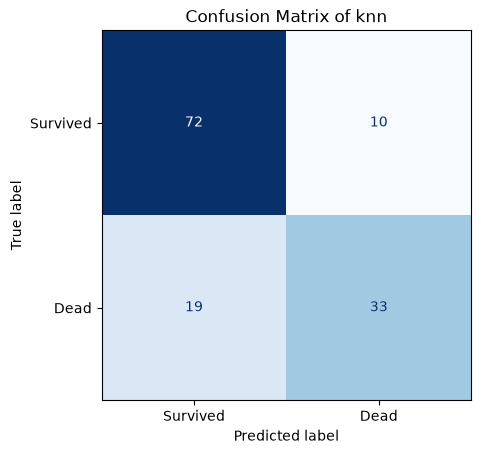

<Figure size 600x600 with 0 Axes>

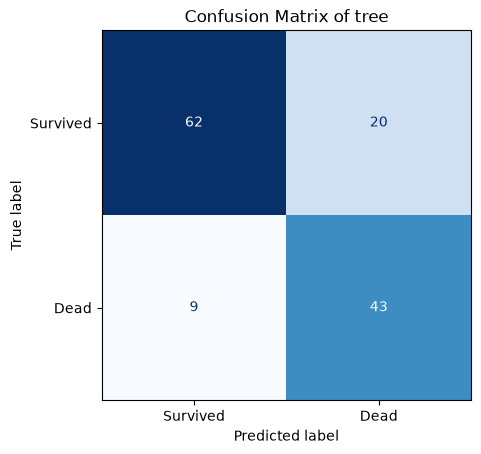

<Figure size 600x600 with 0 Axes>

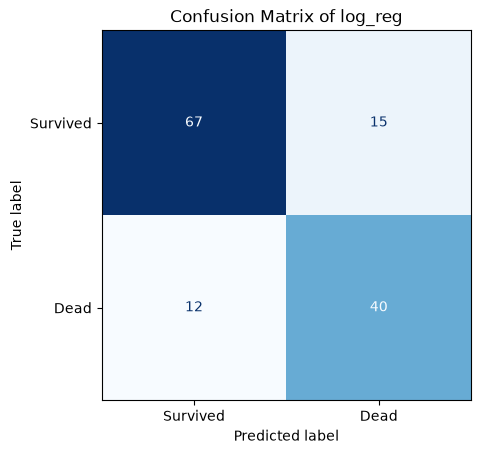

<Figure size 600x600 with 0 Axes>

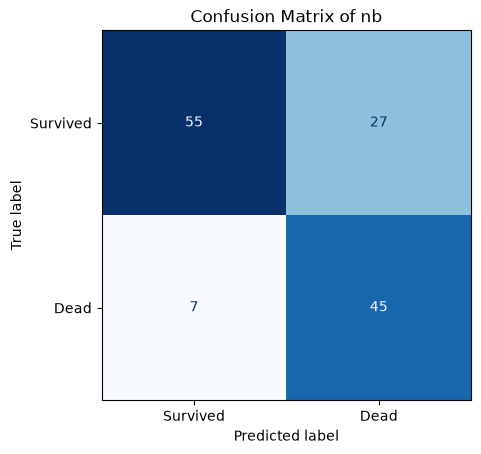

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
def conf_matrix(model, model_name, test_x, test_y):
    plt.figure(figsize=(6,6))
    ConfusionMatrixDisplay.from_estimator(estimator = model, X=test_x, y=test_y, display_labels=['Survived','Dead'],cmap='Blues',colorbar=False)
    plt.title(f"Confusion Matrix of {model_name}")
    plt.show()

for model in models:
    conf_matrix(models[model],model, x_test,y_test)

widać że model regresji logistycznej działa sobie najlepiej w przypadku obu testów, warto też się przyjżeć treeregresion ewentualnie bo w obu jest na 2 miejscu spośród modeli, dostroję metody za pomocą grid searcha

In [24]:
from sklearn.model_selection import GridSearchCV

tree = DecisionTreeClassifier(random_state=42)
log_reg=LogisticRegression(max_iter=1000, random_state=42)

def grid_search_score(model, param_grid, scoring):
    grid_search = GridSearchCV(estimator = model, param_grid=param_grid,cv=5,scoring=scoring)
    grid_search.fit(x_train,y_train)
    print(f"best score: {grid_search.best_score_:.4f}")
    return grid_search

tree_param_grid={
    'criterion': ['gini', 'entropy'],         
    'max_depth': [3, 4, 5, 6, 7, 10, 12, 15, 17, 20, 30, None],    
    'min_samples_split': [2, 5, 8, 10, 12, 15, 20, 25],      
    'min_samples_leaf': [1, 2, 4, 10]          
}

log_reg_param_grid={
    'C': [0.001, 0.01, 0.1, 1, 10 ] #, 100, 1000]ustawiłoem do 10 bo dla 100 i 1000 grid search głupieje i overfituje model i na końcu, na zbiorze walidacyjnym jest gorszy wynik niż dla c= 10 
}
grid_tree_f1 = grid_search_score(tree,tree_param_grid,scoring='f1')
grid_log_reg_f1= grid_search_score(log_reg,log_reg_param_grid,scoring='f1')

best_tree=grid_tree_f1.best_estimator_
best_log_reg=grid_log_reg_f1.best_estimator_


best score: 0.7083
best score: 0.7282


tutaj jeszcze porównanie najlepszego modelu z grid_search z zbiorem testowym z metryuką accuracy i poniżej f1 i jednak widać że regresja logistyczna radzi se najlepiej

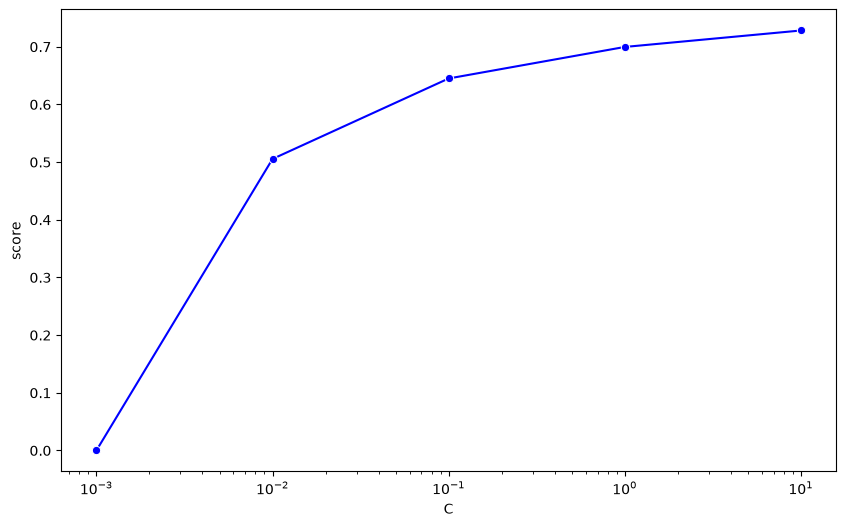

In [25]:
param_values = grid_log_reg_f1.cv_results_['param_C']
mean_scores = grid_log_reg_f1.cv_results_['mean_test_score']

result_df=pd.DataFrame({'C':param_values,'score':mean_scores})
result_df=result_df.sort_values(by='C')

plt.figure(figsize=(10,6))

sns.lineplot(data=result_df, x='C',y='score',marker='o', linestyle='-',color='b')

plt.xscale('log')#ustawiam skalę logarytmiczną bo c jest rozmieszczone wykładniczo

plt.show()

            


jak widać na wykresie najlepszy wynik regresja logistyczna osiąga dla C=10 można przeepuszczać że wartości C<10 sprawiają że model jest nie dotrenowany a wartości C>10 sprawiają że model jest przetrenowany i w sumie tak jest bo defakto parametr C odpowiada za to jak bardzo model dopasowuje się pod dane 

dla drzewa jako że jest tam więcej hiperparametrów niż 1 zrobię wykres wyników dla danego hiperparametru kiedy reszta hiperparametrów jest ustawiona zgodnie z best_params_

Parametr: max_depth | Liczba wierszy po filtrze: 12


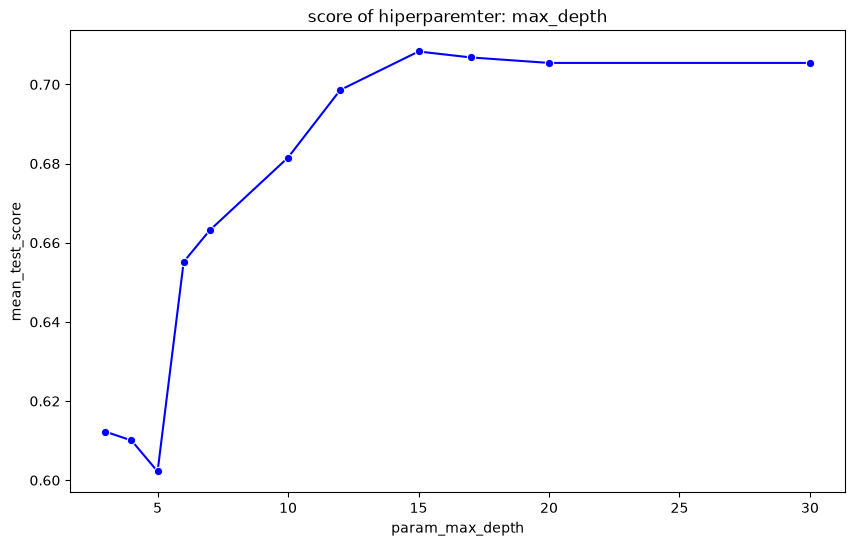

In [26]:
def plot_hyperparameter(param_name,df,best_params):
    other_params = best_params.copy()
    other_params.pop(param_name)#najlepsze parametry z wyjątkiem tego co robimy wykres

    df=pd.DataFrame(df).copy()
    
    
    filtr=True
    for key, val in other_params.items():
        if isinstance(val, str):
            filtr=filtr & (df[f'param_{key}']==val)
        else:
            col_series = pd.to_numeric(df[f'param_{key}']) #zmienieam wartości aby było na pewno numeric bo był z tym problem
            val=pd.to_numeric(val) if val is not None else None
            filtr=filtr & (col_series==val) #tworzymy filtr na te parametry co mają taką samą wartość jak te najlepsze

        
    filtered_df = df[filtr].copy().sort_values(by=f'param_{param_name}')#filtrujemy i sortujemy df z każdą możliwą kombinacją hiperparametrów
    print(f"Parametr: {param_name} | Liczba wierszy po filtrze: {len(filtered_df)}")
    plt.figure(figsize=(10,6))

    sns.lineplot(
        data=filtered_df,
        x=f'param_{param_name}',
        y='mean_test_score',
        marker='o',
        color='b')
    plt.title(f'score of hiperparemter: {param_name}')
    plt.show()

plot_hyperparameter('max_depth',grid_tree_f1.cv_results_.copy(),grid_tree_f1.best_params_)


    

dla max_depth sytuacja wygląda podobnie jak dla hipeparametru C z poprzedniego przykładu czyli na początku są słabe wyniki w wyniku przetrenowania, po czym się przetrenowuje

Parametr: min_samples_split | Liczba wierszy po filtrze: 8


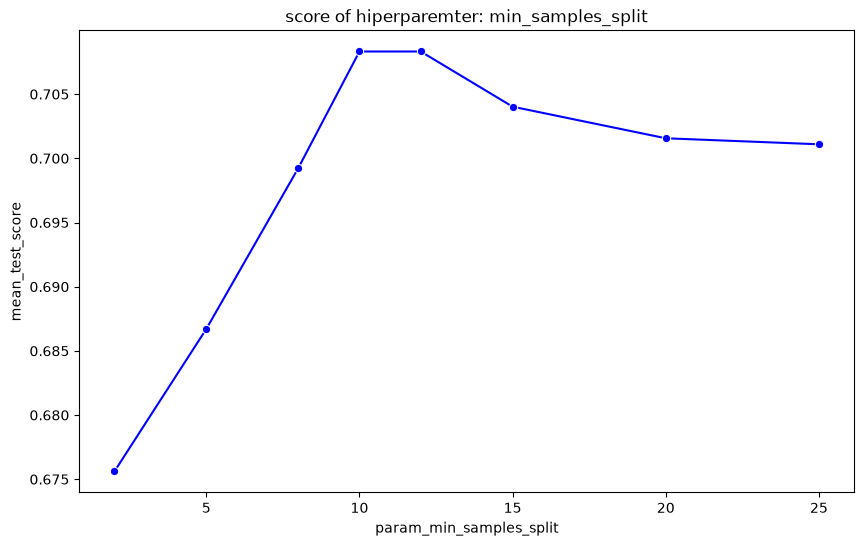

In [27]:
plot_hyperparameter('min_samples_split',grid_tree_f1.cv_results_.copy(),grid_tree_f1.best_params_)

tutaj sprawa wygląda inaczej bo ten parametr określa minimalną ilość próbek które idą do gałęzi drzewa aby model uznał że sensowne jest jej podzielenie w skrucie im mniejsza wartość tym większe przetrenowanie 

Parametr: min_samples_leaf | Liczba wierszy po filtrze: 4


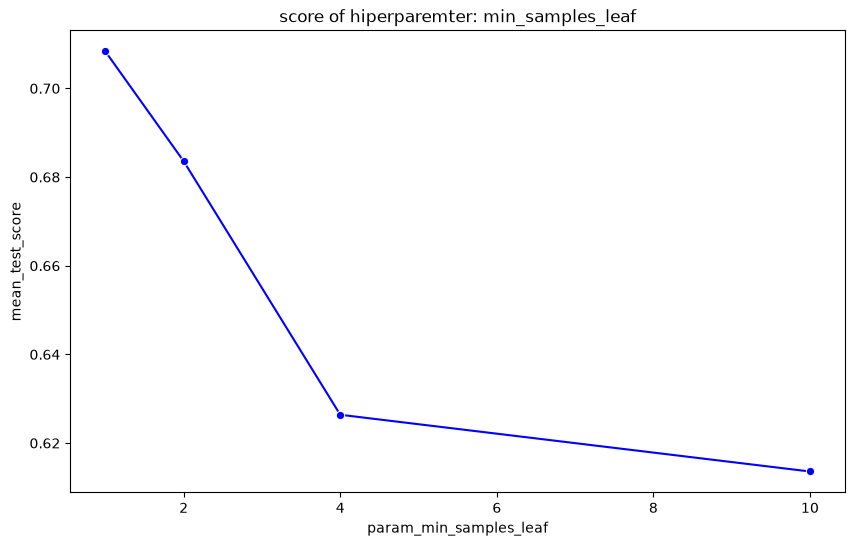

In [28]:
plot_hyperparameter('min_samples_leaf',grid_tree_f1.cv_results_.copy(),grid_tree_f1.best_params_)

ten hiperparametr określa ile minimalnie próbek ma wylądować w liściu czyli też im mniejsza wartość tym większe przetrenowanie, minimalną wartością z definicji jest jeden o dziwo dla 1 osiąga najlepsze rezultaty być może jest to spowodowane tym że zbiór titanica jest bardzo mały

In [29]:
print(f"tree:{best_tree.score(x_test,y_test)}")
print(f"log_reg:{best_log_reg.score(x_test,y_test)}")

tree:0.8059701492537313
log_reg:0.8208955223880597


In [30]:
 print(f"tree:{f1_score(y_test,best_tree.predict(x_test))}")
 print(f"log_reg:{f1_score(y_test,best_log_reg.predict(x_test))}")

tree:0.7719298245614035
log_reg:0.7777777777777778


teraz po przetestowaniu modeli i ustawieniu hiperparametrów można zobaczyć jaki jest ich faktyczny accuracy na zbiorach walidacyjnych, oba modele radzą se podobnie w obu metrykach więc jedyne co zostało to zobaczyć ich skore na zbiorze walidacyjnym

log_reg score:0.8175182481751825
log_reg f1 :0.7524752475247525
tree score:0.7956204379562044
tree f1:0.7307692307692307


<Figure size 600x600 with 0 Axes>

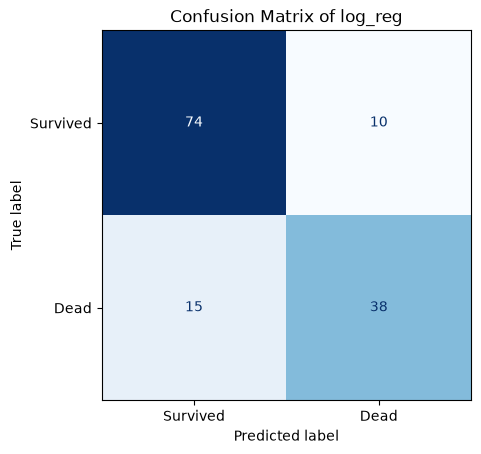

<Figure size 600x600 with 0 Axes>

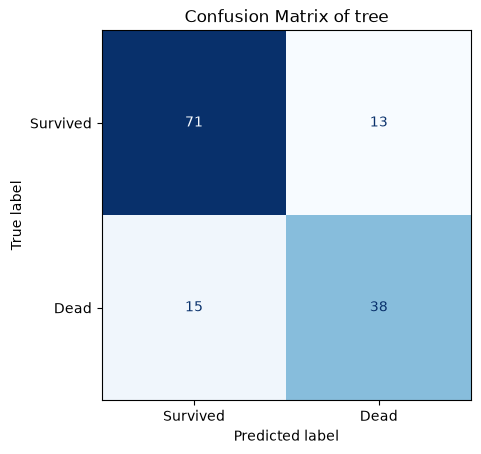

In [32]:
print(f"log_reg score:{best_log_reg.score(x_valid,y_valid)}")
print(f"log_reg f1 :{f1_score(y_valid,best_log_reg.predict(x_valid))}")
print(f"tree score:{best_tree.score(x_valid,y_valid)}")
print(f"tree f1:{f1_score(y_valid,best_tree.predict(x_valid))}")

conf_matrix(best_log_reg,"log_reg",x_valid, y_valid)
conf_matrix(best_tree,"tree",x_valid, y_valid)

podsumowując najlepszym modelem do tego zadania z pośród badanych przezemnie jest regresja logistyczna ze skutecznością ~82% w zwykłym accuracy i ~75% w  f1 :)